# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [91]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

In [48]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB


In [50]:
df.describe()

,Age,Number of Children
count,130.000000,164.000000
mean,37.507692,0.652439
std,8.500110,0.883346
min,25.000000,0.000000
25%,30.000000,0.000000
50%,36.000000,0.000000
75%,45.000000,1.000000
max,53.000000,3.000000


In [51]:
df.isnull().sum()

Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64

In [57]:
df['Income'] = (
    df['Income']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    float64
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.4+ KB


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [ ]:
'''
Justificativa: A mediana é menos sensível a valores extremos (outliers) do que a média,
preservando melhor a distribuição central da idade.
'''

In [73]:
df['Age'] = df['Age'].fillna(df['Age'].median())

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [ ]:
'''
Todos as variáveis categóricas estao corretamente digitadas
'''

In [15]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [16]:
df['Education'].unique()

array(["Bachelor's Degree", "Master's Degree", 'Doctorate',
       'High School Diploma', "Associate's Degree"], dtype=object)

In [17]:
df['Marital Status'].unique()

array(['Single', 'Married'], dtype=object)

In [18]:
df['Home Ownership'].unique()

array(['Rented', 'Owned'], dtype=object)

In [19]:
df['Credit Score'].unique()

array(['High', 'Average', 'Low'], dtype=object)

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [26]:
df.describe()

,Age,Number of Children
count,164.000000,164.000000
mean,37.195122,0.652439
std,7.586619,0.883346
min,25.000000,0.000000
25%,31.750000,0.000000
50%,36.000000,0.000000
75%,43.000000,1.000000
max,53.000000,3.000000


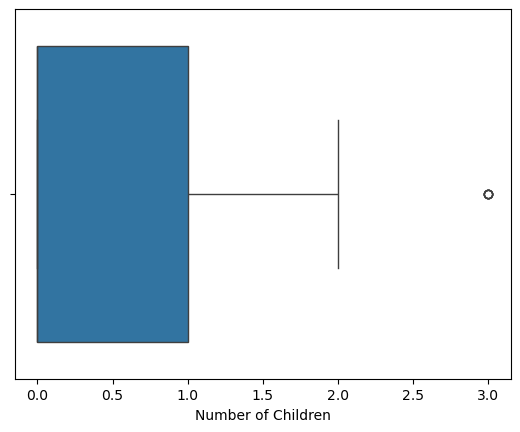

In [25]:
sns.boxplot(x=df['Number of Children'])
plt.show() # não faz sentido considerar uma pessoa com 3 filhos um outlier

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

/var/folders/9n/z6l5csrx10zdsy42b_30trwh0000gn/T/ipykernel_84074/1014655102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Credit Score', y='Income', palette='Set2')


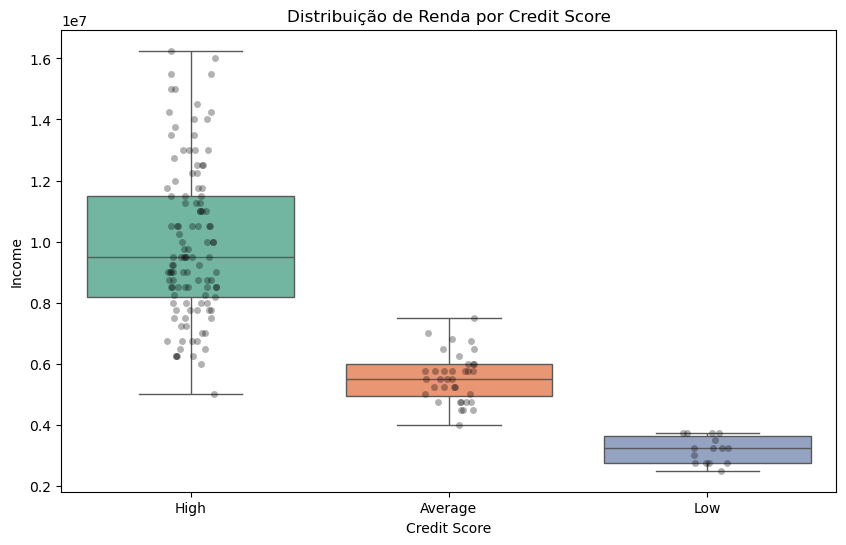

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Credit Score', y='Income', palette='Set2')
sns.stripplot(data=df, x='Credit Score', y='Income', color='black', alpha=0.3)
plt.title('Distribuição de Renda por Credit Score')
plt.show()

/var/folders/9n/z6l5csrx10zdsy42b_30trwh0000gn/T/ipykernel_84074/3484391706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Credit Score', y='Age', palette='Set2')


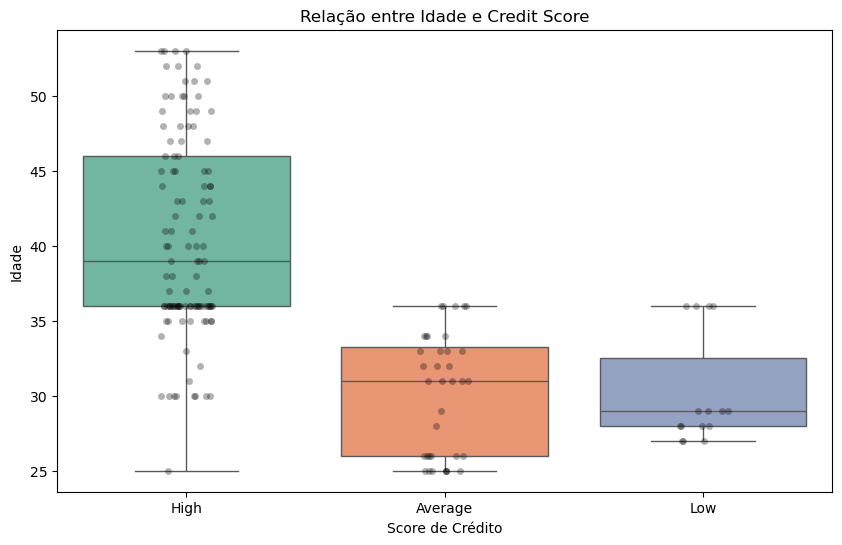

In [74]:
plt.figure(figsize=(10, 6))
# Plota o boxplot base
sns.boxplot(data=df, x='Credit Score', y='Age', palette='Set2')
# Sobrepõe os pontos individuais (ideal para N pequeno)
sns.stripplot(data=df, x='Credit Score', y='Age', color='black', alpha=0.3)

plt.title('Relação entre Idade e Credit Score')
plt.xlabel('Score de Crédito')
plt.ylabel('Idade')
plt.show()

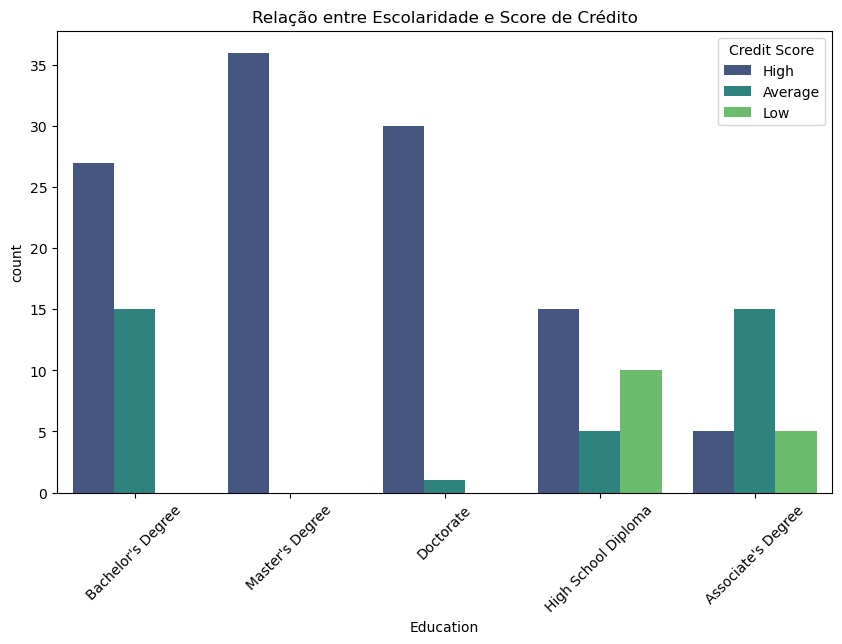

In [67]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Education', hue='Credit Score', palette='viridis')
plt.title('Relação entre Escolaridade e Score de Crédito')
plt.xticks(rotation=45)
plt.legend(title='Credit Score')
plt.show()

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [79]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

print(f"O limite superior é: {limite_superior}")
print(f"Quantidade de outliers: {df[df['Income'] > limite_superior].shape[0]}")

O limite superior é: 17625000.0
Quantidade de outliers: 0


In [80]:
# a base de dados é pequena então fica mais fácil 
df['Income'] = np.where(df['Income'] > limite_superior, limite_superior, df['Income'])

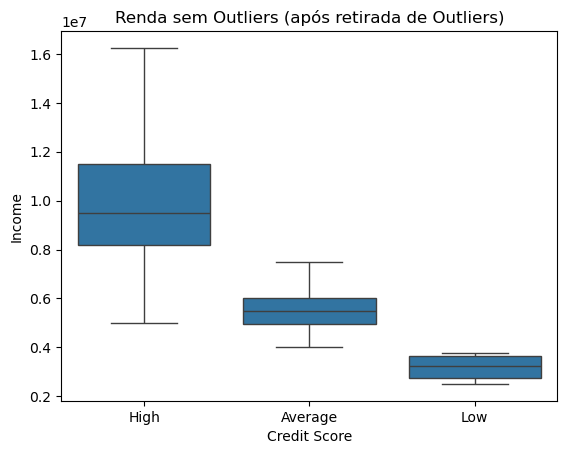

In [81]:
sns.boxplot(data=df, x='Credit Score', y='Income')
plt.title("Renda sem Outliers (após retirada de Outliers)")
plt.show()

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



/var/folders/9n/z6l5csrx10zdsy42b_30trwh0000gn/T/ipykernel_84074/1291708056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Marital Status', y='Age', palette='pastel')


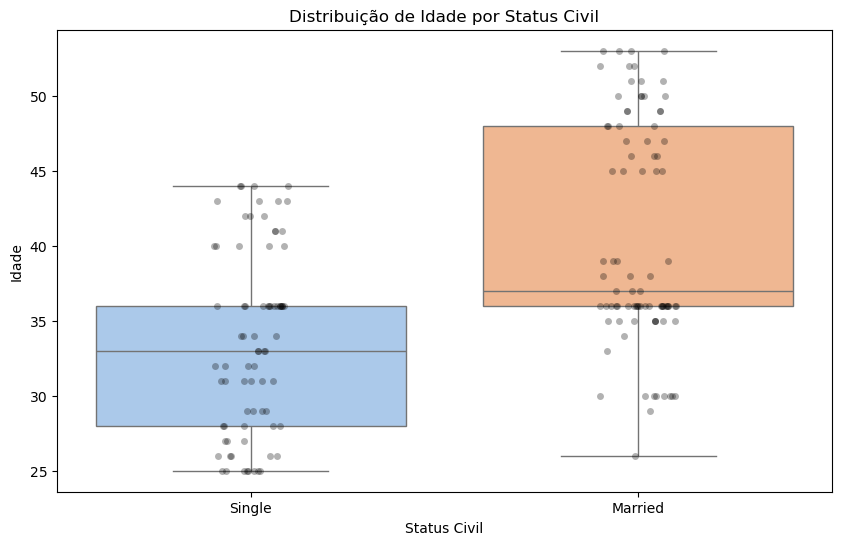

In [82]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='Marital Status', y='Age', palette='pastel')
sns.stripplot(data=df, x='Marital Status', y='Age', color='black', alpha=0.3)

plt.title('Distribuição de Idade por Status Civil')
plt.xlabel('Status Civil')
plt.ylabel('Idade')
plt.show()

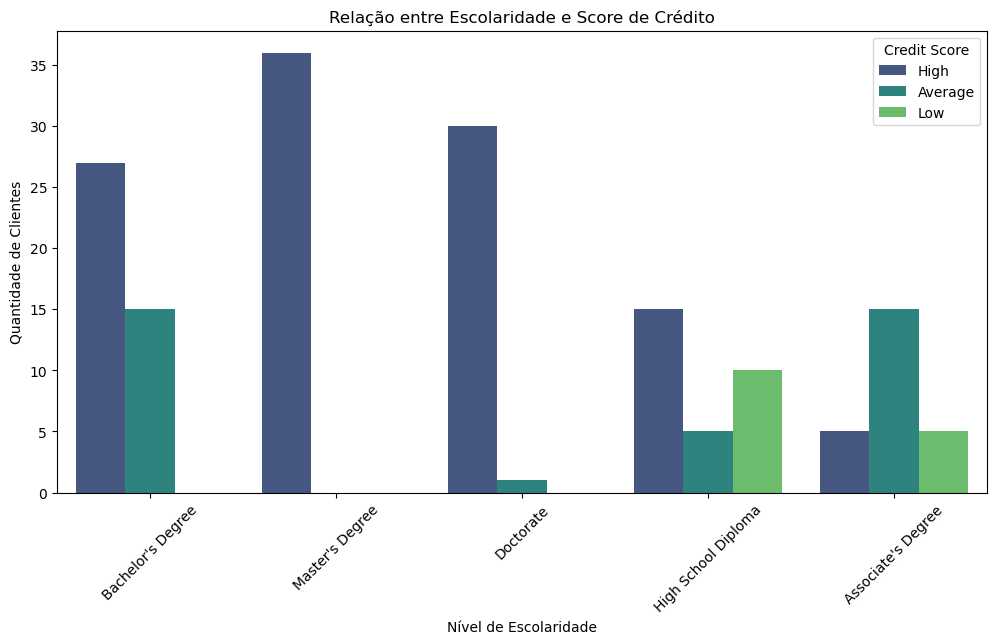

In [83]:
plt.figure(figsize=(12, 6))

ordem_educacao = df['Education'].value_counts().index

sns.countplot(data=df, x='Education', hue='Credit Score', order=ordem_educacao, palette='viridis')

plt.title('Relação entre Escolaridade e Score de Crédito')
plt.xlabel('Nível de Escolaridade')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=45)
plt.legend(title='Credit Score')
plt.show()

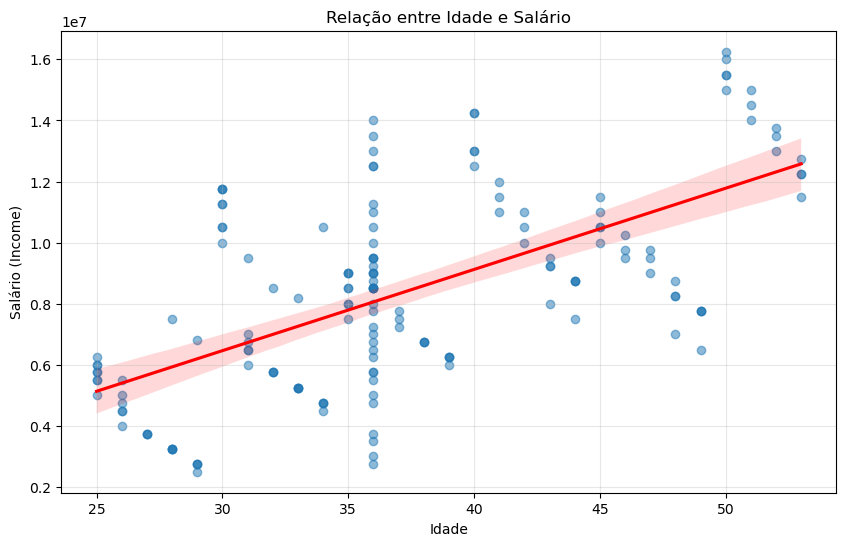

In [84]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='Age', y='Income', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relação entre Idade e Salário')
plt.xlabel('Idade')
plt.ylabel('Salário (Income)')
plt.grid(True, alpha=0.3)
plt.show()

In [85]:
correlacao = df[['Age', 'Income']].corr().iloc[0, 1]
print(f"O coeficiente de correlação entre Idade e Salário é: {correlacao:.2f}")

O coeficiente de correlação entre Idade e Salário é: 0.62


/var/folders/9n/z6l5csrx10zdsy42b_30trwh0000gn/T/ipykernel_84074/1968050232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Credit Score', y='Income', palette='coolwarm', order=['Low', 'Average', 'High'])


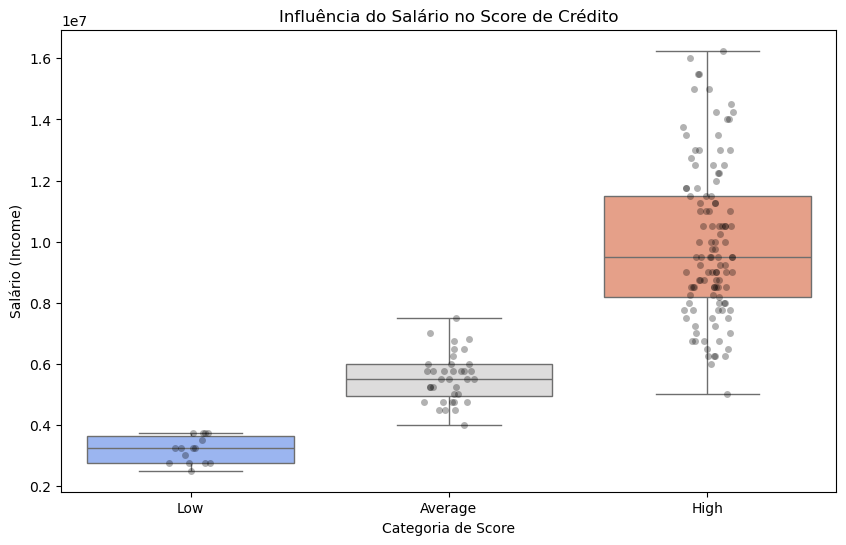

In [86]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='Credit Score', y='Income', palette='coolwarm', order=['Low', 'Average', 'High'])

sns.stripplot(data=df, x='Credit Score', y='Income', color='black', alpha=0.3, order=['Low', 'Average', 'High'])

plt.title('Influência do Salário no Score de Crédito')
plt.xlabel('Categoria de Score')
plt.ylabel('Salário (Income)')
plt.show()

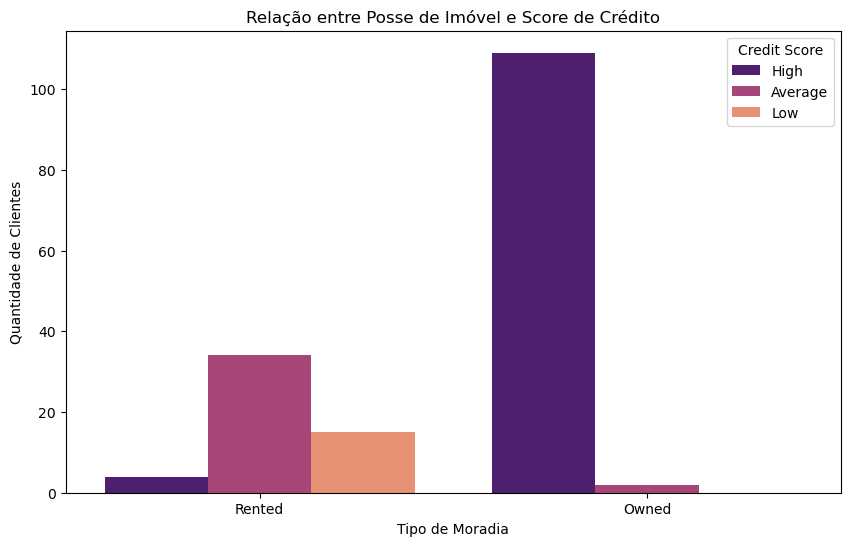

In [87]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Home Ownership', hue='Credit Score', palette='magma')

plt.title('Relação entre Posse de Imóvel e Score de Crédito')
plt.xlabel('Tipo de Moradia')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Credit Score')
plt.show()

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

In [ ]:
# O número de filhos impacta a categoria de Score de Crédito?

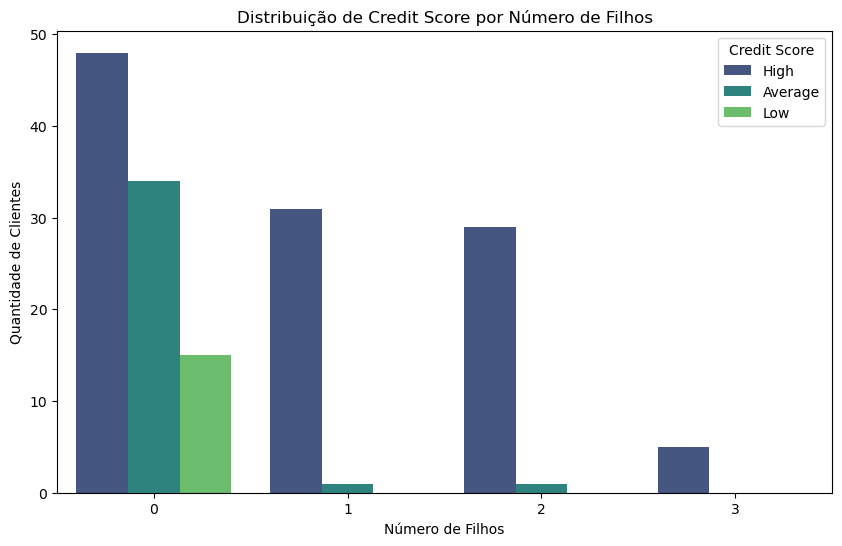

In [88]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Number of Children', hue='Credit Score', palette='viridis')
plt.title('Distribuição de Credit Score por Número de Filhos')
plt.xlabel('Número de Filhos')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [ ]:
# Qual a relação entre Escolaridade e Renda (Income)?

/var/folders/9n/z6l5csrx10zdsy42b_30trwh0000gn/T/ipykernel_84074/407012080.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education', y='Income', palette='Set3', order=df.groupby('Education')['Income'].median().sort_values().index)


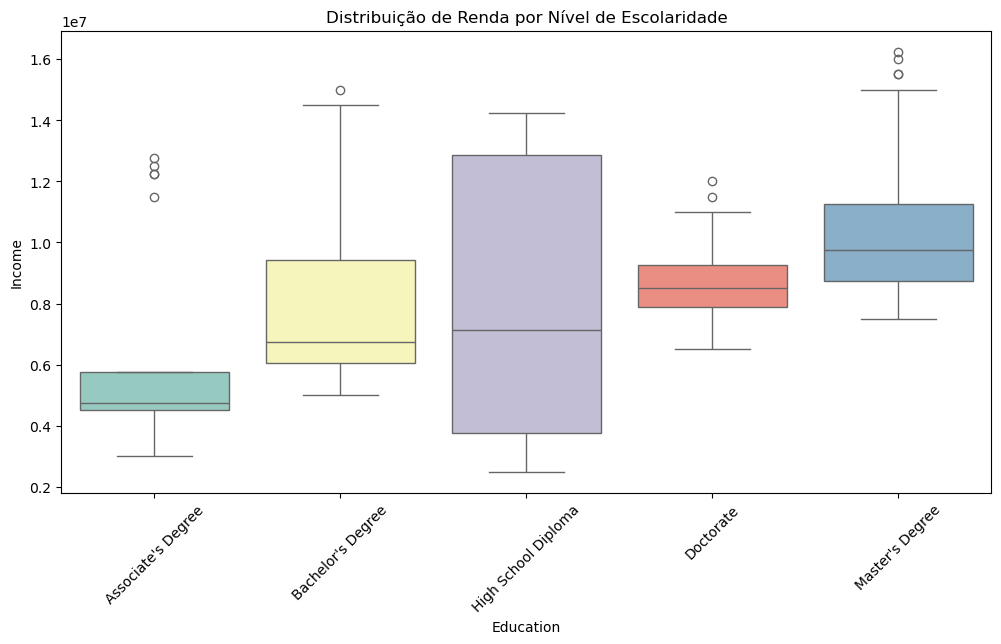

In [89]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Education', y='Income', palette='Set3', order=df.groupby('Education')['Income'].median().sort_values().index)
plt.xticks(rotation=45)
plt.title('Distribuição de Renda por Nível de Escolaridade')
plt.show()

In [ ]:
# Como a Idade e a Renda interagem simultaneamente com o Score de Crédito?

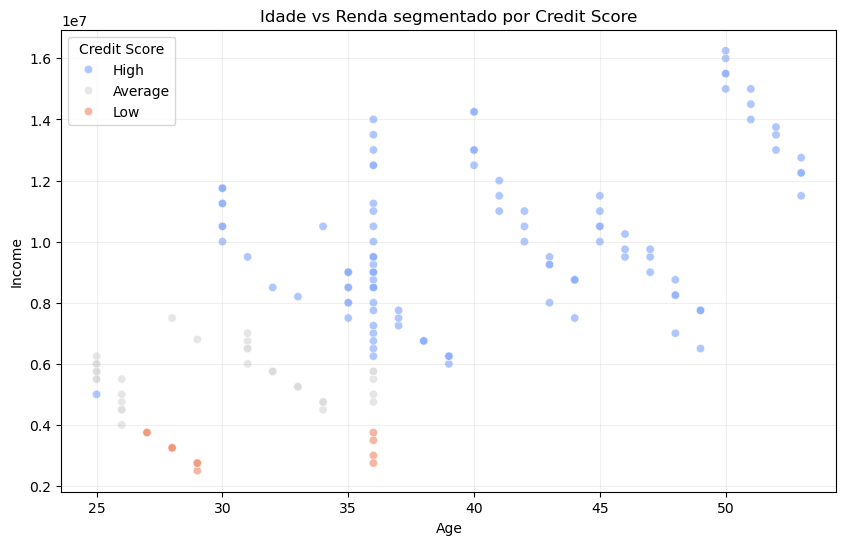

In [90]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Income', hue='Credit Score', palette='coolwarm', alpha=0.7)
plt.title('Idade vs Renda segmentado por Credit Score')
plt.grid(True, alpha=0.2)
plt.show()

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

In [92]:
df_corr = df.copy()
le = LabelEncoder()
# Lista de colunas categóricas para converter
cat_cols = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']

for col in cat_cols:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

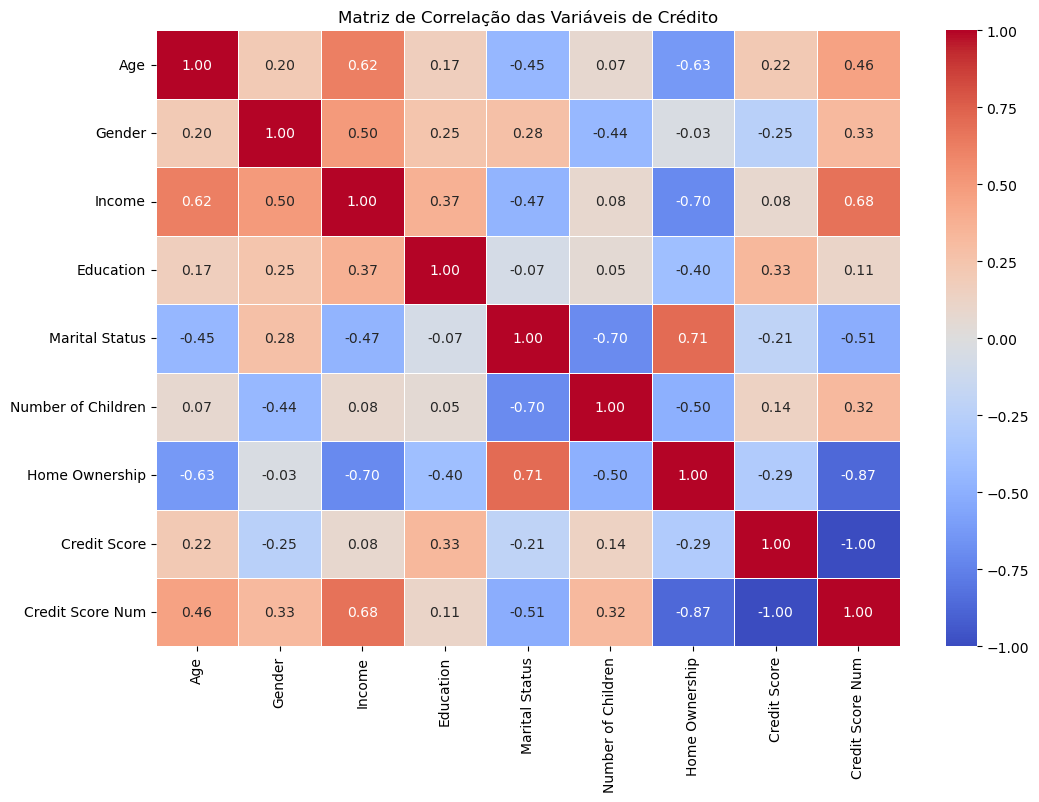

In [93]:
matriz_corr = df_corr.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis de Crédito')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [ ]:
'''
Idade vs. Renda: Faz sentido devido ao plano de carreira. 
Profissionais mais velhos tendem a ocupar cargos de senioridade ou gerência,
acumulando maior capital e experiência, o que eleva a média salarial em relação a jovens em início de carreira.
Escolaridade vs. Renda: Existe uma relação direta entre o nível de especialização e o valor
da hora técnica ou do cargo ocupado. Historicamente, graus acadêmicos como mestrado e 
doutorado abrem portas para faixas salariais que não são acessíveis com apenas o ensino médio.
Renda vs. Credit Score: Para as instituições financeiras, a renda é um indicador de 
capacidade de pagamento. Embora o score avalie o comportamento (pagar em dia), a folga 
financeira proporcionada por um salário maior reduz a probabilidade de 
inadimplência por necessidade, elevando a pontuação.
'''

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [94]:
from sklearn.preprocessing import LabelEncoder

# Instanciando o encoder
le = LabelEncoder()

# Aplicando no Credit Score (Target)
df['Credit Score'] = le.fit_transform(df['Credit Score'])

# Dica: Verifique a ordem (Ex: 0=Average, 1=High, 2=Low)
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapeamento do Score: {mapping}")

Mapeamento do Score: {'Average': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2)}


In [95]:
# Lista de colunas para One-Hot Encoding
cols_para_converter = ['Gender', 'Education', 'Marital Status', 'Home Ownership']

# Aplicando One-Hot Encoding e removendo as originais automaticamente
df_final = pd.get_dummies(df, columns=cols_para_converter)

# Visualizando o novo formato das colunas
print(df_final.head())

    Age      Income  Number of Children  Credit Score  Credit Score Num  \
0  25.0   5000000.0                   0             1               2.0   
1  30.0  10000000.0                   2             1               2.0   
2  35.0   7500000.0                   1             1               2.0   
3  40.0  12500000.0                   0             1               2.0   
4  45.0  10000000.0                   3             1               2.0   

   Gender_Female  Gender_Male  Education_Associate's Degree  \
0           True        False                         False   
1          False         True                         False   
2           True        False                         False   
3          False         True                         False   
4           True        False                         False   

   Education_Bachelor's Degree  Education_Doctorate  \
0                         True                False   
1                        False                False   
2    

In [96]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            164 non-null    float64
 1   Income                         164 non-null    float64
 2   Number of Children             164 non-null    int64  
 3   Credit Score                   164 non-null    int64  
 4   Credit Score Num               128 non-null    float64
 5   Gender_Female                  164 non-null    bool   
 6   Gender_Male                    164 non-null    bool   
 7   Education_Associate's Degree   164 non-null    bool   
 8   Education_Bachelor's Degree    164 non-null    bool   
 9   Education_Doctorate            164 non-null    bool   
 10  Education_High School Diploma  164 non-null    bool   
 11  Education_Master's Degree      164 non-null    bool   
 12  Marital Status_Married         164 non-null    boo

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

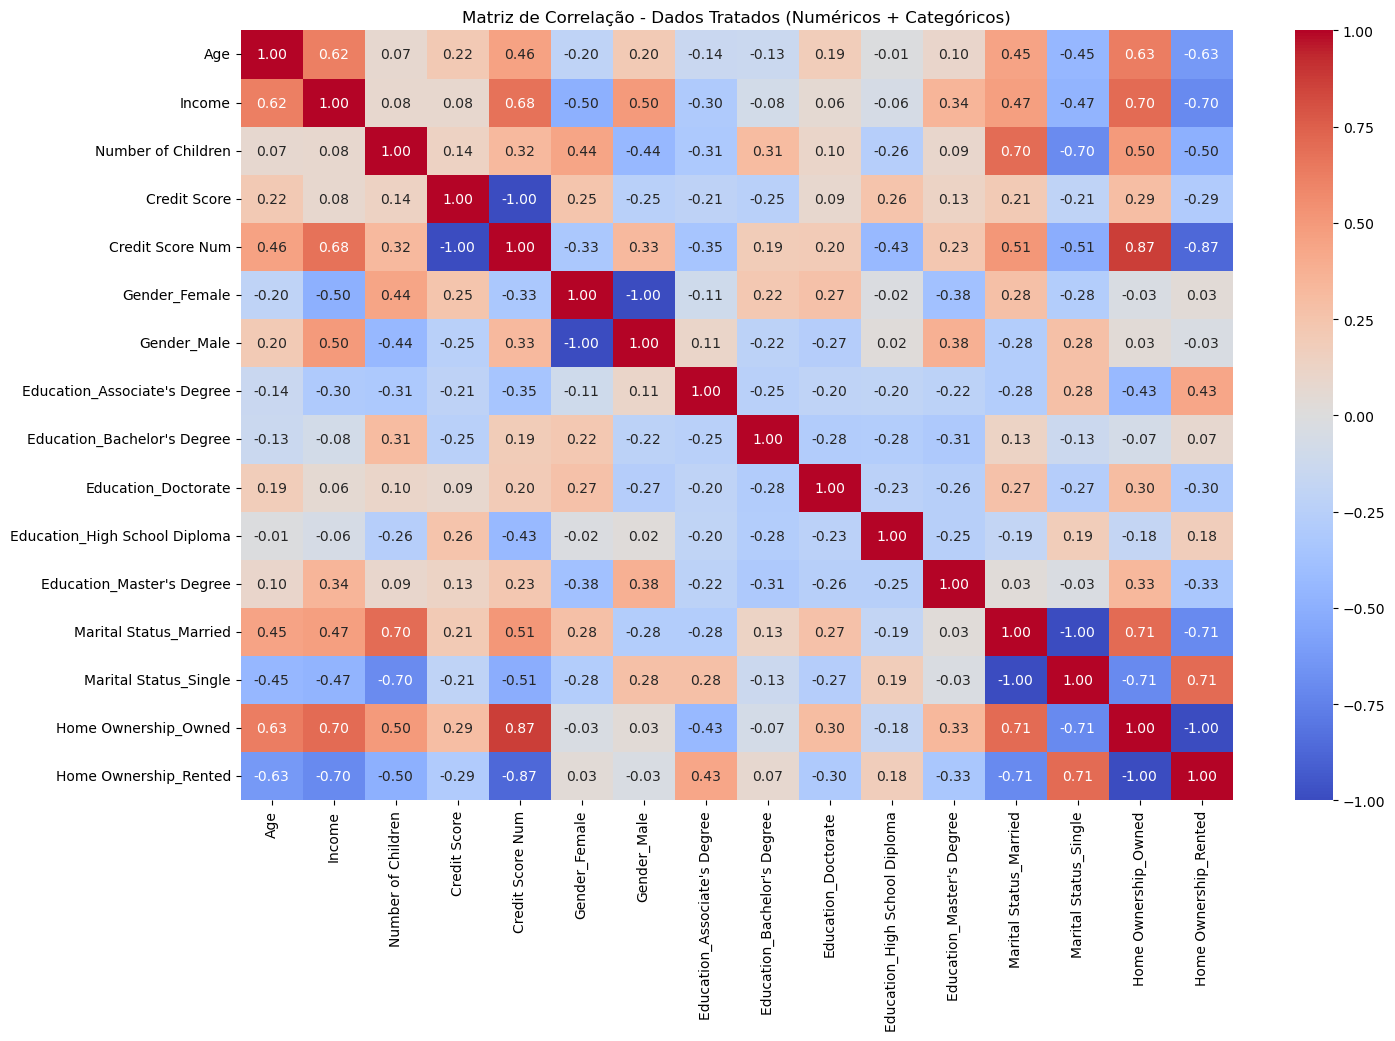

In [97]:
# Calcula a correlação no dataframe tratado
# Se usou get_dummies, o df_final terá colunas como 'Education_Doctorate', etc.
plt.figure(figsize=(16, 10))
matriz_final = df_final.corr()

# Plotando com ajuste de visualização para muitas colunas
sns.heatmap(matriz_final, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlação - Dados Tratados (Numéricos + Categóricos)')
plt.show()

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [98]:
from sklearn.model_selection import train_test_split

X = df_final.drop('Credit Score', axis=1)
y = df_final['Credit Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Formato da base original: {df_final.shape}")
print(f"Formato de X_train (Treino): {X_train.shape}")
print(f"Formato de X_test (Teste): {X_test.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de y_test: {y_test.shape}")

Formato da base original: (164, 16)
Formato de X_train (Treino): (114, 15)
Formato de X_test (Teste): (50, 15)
Formato de y_train: (114,)
Formato de y_test: (50,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

/var/folders/9n/z6l5csrx10zdsy42b_30trwh0000gn/T/ipykernel_84074/639528122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


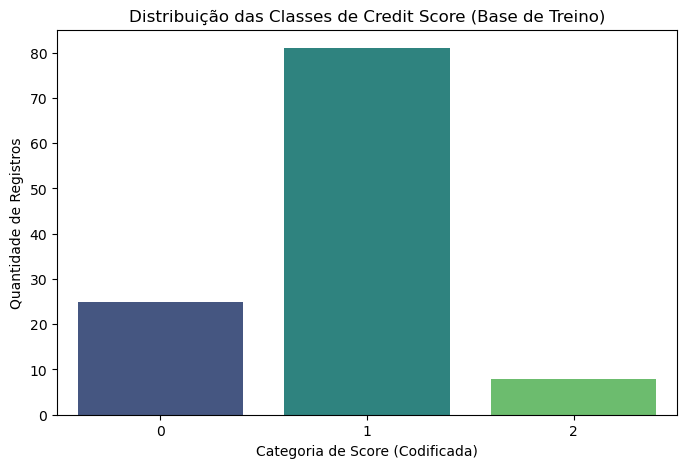

Credit Score
1    71.052632
0    21.929825
2     7.017544
Name: proportion, dtype: float64


In [99]:
plt.figure(figsize=(8, 5))
# Verificando a distribuição na base original ou no y_train
sns.countplot(x=y_train, palette='viridis')

plt.title('Distribuição das Classes de Credit Score (Base de Treino)')
plt.xlabel('Categoria de Score (Codificada)')
plt.ylabel('Quantidade de Registros')
plt.show()

# Verificação numérica
print(y_train.value_counts(normalize=True) * 100)

In [ ]:
'''
O modelo possui um desbalanceamento pois as colunas estão desparelhas.
'''

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [108]:
print(df_final.isnull().sum())
df_final['Age'] = df_final['Age'].fillna(df_final['Age'].median())
df_final = df_final.fillna(0) 

X = df_final.drop('Credit Score', axis=1)
y = df_final['Credit Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Balanceamento concluído com sucesso.")

Age                              0
Income                           0
Number of Children               0
Credit Score                     0
Credit Score Num                 0
Gender_Female                    0
Gender_Male                      0
Education_Associate's Degree     0
Education_Bachelor's Degree      0
Education_Doctorate              0
Education_High School Diploma    0
Education_Master's Degree        0
Marital Status_Married           0
Marital Status_Single            0
Home Ownership_Owned             0
Home Ownership_Rented            0
dtype: int64
Balanceamento concluído com sucesso.


/var/folders/9n/z6l5csrx10zdsy42b_30trwh0000gn/T/ipykernel_84074/3129917726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='viridis')


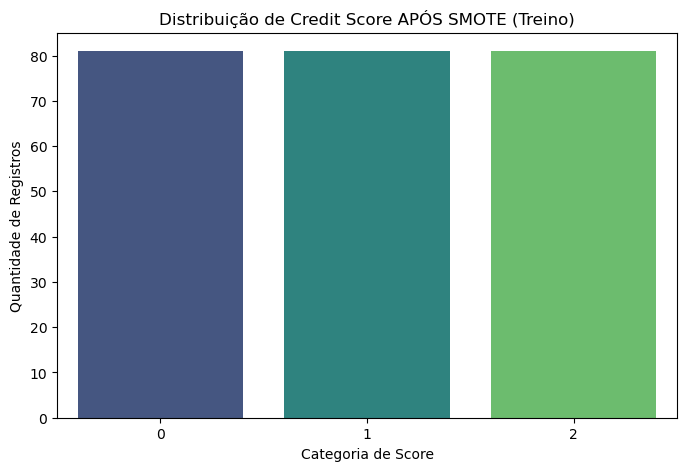

In [109]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_res, palette='viridis')
plt.title('Distribuição de Credit Score APÓS SMOTE (Treino)')
plt.xlabel('Categoria de Score')
plt.ylabel('Quantidade de Registros')
plt.show()